In [ ]:
!pip install vmas

In [ ]:

!sudo apt-get update
!sudo apt-get install python3-opengl xvfb
!pip install pyvirtualdisplay
import pyvirtualdisplay
display = pyvirtualdisplay.Display(visible=False, size=(1400, 900))
display.start()

In [21]:
from typing import Optional, Union
import time

import torch
from vmas.simulator.core import Agent, Landmark, World, Box, Sphere
from vmas.simulator.scenario import BaseScenario
from vmas.simulator.utils import Color
from vmas.simulator.sensors import Lidar
from vmas import make_env
from vmas.simulator.utils import ScenarioUtils

In [95]:
# Make custom scenario

# NOTE: The code for this class was provided by Gemini
# but I typed the whole thing myself
class WindNavScenario(BaseScenario):

    def make_world(self, batch_dim: int, device: torch.device, **kwargs):
        # initialize world
        world = World(
            dim_c=0, # Number of communication channels if any
            substeps=1,
            batch_dim=batch_dim,
            device=device,
            **kwargs
        )

        self.num_agents = kwargs.pop("num_agents", 3)
        self.num_obstacles = kwargs.pop("num_obstacles", 10)

        self.agent_radius = kwargs.pop("agent_radius", 0.1)

        self.lidar_range = kwargs.pop("lidar_range", 0.3)  # Range of the LIDAR sensor
        self.n_lidar_rays = kwargs.pop(
            "n_lidar_rays", 8
        )  # Number of LIDAR rays around the agent, each ray gives an observation between 0 and lidar_range

        # X-coordinate limit for entities spawning
        self.world_spawning_x = kwargs.pop("world_spawning_x", 1)
        # Y-coordinate limit for entities spawning
        self.world_spawning_y = kwargs.pop("world_spawning_y", 1)

        self.min_distance_between_entities = (
            self.agent_radius * 2 + 0.05
        )  # Minimum distance between entities at spawning time
        self.min_collision_distance = (
            0.005  # Minimum distance between entities for collision trigger
        )

        ScenarioUtils.check_kwargs_consumed(kwargs) # Warn if not all kwargs have been consumed

        # initialize goal(s)
        # Single goal for now
        goal = Landmark(
            name="goal",
            collide=False,
            movable=False,
            shape=Sphere(radius=0.05),
            color=Color.GREEN,
        )
        world.add_landmark(goal)

        # initialize agents
        for i in range(self.num_agents):
            sensors = [
                Lidar(
                        world,
                        n_rays=self.n_lidar_rays,
                        max_range=self.lidar_range,
                        entity_filter=lambda e: isinstance(
                            e, Agent
                        ),  # This makes sure that this lidar only percieves other agents
                        angle_start=0.0,  # LIDAR angular ranges (we sense 360 degrees)
                        angle_end=2
                        * torch.pi,  # LIDAR angular ranges (we sense 360 degrees)
                        render=True,
                        render_color=Color.BLACK
                    )
                ]  # Agent LIDAR sensor

            agent = Agent(
                name=f"agent_{i}",
                collide=True,
                sensors=sensors, # give agent the sensors
                render_action=True,
                shape=Sphere(radius=self.agent_radius),
                color=Color.BLUE,
                max_speed=1.0
            )
            world.add_agent(agent)
            agent.goal = goal


        # configure rectangular obstacles
        for i in range(self.num_obstacles):
            obstacle = Landmark(
                name=f"obstacle_{i}",
                collide=True,
                movable=False,
                shape=Box(length=0.3, width=0.1),
                color=Color.RED,
            )
            world.add_landmark(obstacle)

        return world

    def reset_world_at(self, env_index):
        ScenarioUtils.spawn_entities_randomly(
            self.world.agents
            + self.world.landmarks,
            self.world,
            env_index, # Pass the env_index so we only reset what needs resetting
            self.min_distance_between_entities,
            x_bounds=(-self.world_spawning_x, self.world_spawning_x),
            y_bounds=(-self.world_spawning_y, self.world_spawning_y),
        )


    def get_wind_force(self, pos: torch.Tensor) -> torch.Tensor:
        """
        Calculates 2D vector field force based on absolute global coordinates
        Args:
            pos: Tensor of shape (n_env, 2) containing coordinates
        Returns:
            force: Tensor of shape (n_env, 2) acting on agents
        """

        x = pos[:, 0]
        y = pos[:, 1]

        wind_x = torch.full_like(x, 0.3)
        # I am guessing we multiplied by pi to make length of a single sin cycle
        # equal to domain of x, which is [0, 1]
        wind_y = 0.1 * torch.sin(x * 3.14159)

        return torch.stack([wind_x, wind_y], dim=1)

    def process_action(self, agent: Agent):
        """
        This hook executes right before the physics step.
        We use it to apply our background wind vector field to all movable agents.
        """
        wind_force = self.get_wind_force(agent.state.pos)

        agent.state.force += wind_force

    def observation(self, agent: Agent):
        # This forces the LIDAR to cast rays
        for sensor in agent.sensors:
            sensor.measure()

        # Must return tensor states for all possible envs
        rel_pos_obstacles = []
        for obstacle in self.world.landmarks:
            rel_pos_obstacles.append(obstacle.state.pos - agent.state.pos)

        rel_pos_agents = []
        for other in self.world.agents:
            if other is not agent:
                rel_pos_agents.append(other.state.pos - agent.state.pos)

        return torch.cat(
            [
                agent.state.pos,
                agent.state.vel,
                *rel_pos_obstacles,
                *rel_pos_agents,
            ],
            dim = 1
        )

    def reward(self, agent: Agent):
        # define cooperative or adversial rewards here

        # For me, it would be cooperative (for search based tasks)
        # Example: Minimize distance to target while penalizing collision

        # Because it is vectorized, return a tensor of shape (n_envs, )
        return torch.zeros(self.world.batch_dim, device=self.world.device)

In [96]:
# Actions will be determined by imported or custom algorithm
# For now import algorithm using RLLib?

In [97]:
# This code was provided by one of the collab notebooks given in VMAS github
# https://colab.research.google.com/github/proroklab/VectorizedMultiAgentSimulator/blob/main/notebooks/VMAS_Use_vmas_environment.ipynb
def use_vmas_env(
        render: bool,
        num_envs: int,
        n_steps: int,
        device: str,
        scenario: Union[str, BaseScenario],
        continuous_actions: bool,
        random_action: bool,
        **kwargs,
        ):
    """
    Perform training
    """

    scenario_name = scenario if isinstance(scenario,str) else scenario.__class__.__name__

    env = make_env(
        scenario=scenario,
        num_envs=num_envs,
        device=device,
        continuous_actions=continuous_actions,
        seed=42,
        **kwargs
    )

    frame_list = []
    init_time = time.time()

    for step in range(1, n_steps+1):
        print(f"Step {step}")

        actions = []
        for i, agent in enumerate(env.agents):
            # decide action using MARL algorithm
            action = env.get_random_action(agent)
            actions.append(action)

        obs, rews, dones, info = env.step(actions)

        if render:
            frame = env.render(
                mode="rgb_array",
                agent_index_focus=None # # Can give the camera an agent index to focus on
            )
            frame_list.append(frame)

    total_time = time.time() - init_time
    print(
        f"It took: {total_time}s for {n_steps} steps of {num_envs} parallel environments on device {device} "
        f"for {scenario_name} scenario."
    )

    if render:
        from moviepy.editor import ImageSequenceClip
        fps = 30
        clip = ImageSequenceClip(frame_list, fps=fps)
        clip.write_gif(f'{scenario_name}.gif', fps=fps)

In [98]:
wind_scenario = WindNavScenario()
scenario_name = wind_scenario.__class__.__name__
use_vmas_env(
    render=True,
    num_envs=10,
    n_steps=50,
    device="cpu",
    scenario=wind_scenario,
    continuous_actions=True,
    random_action=True,
)

Step 1
Step 2
Step 3
Step 4
Step 5
Step 6
Step 7
Step 8
Step 9
Step 10
Step 11
Step 12
Step 13
Step 14
Step 15
Step 16
Step 17
Step 18
Step 19
Step 20
Step 21
Step 22
Step 23
Step 24
Step 25
Step 26
Step 27
Step 28
Step 29
Step 30
Step 31
Step 32
Step 33
Step 34
Step 35
Step 36
Step 37
Step 38
Step 39
Step 40
Step 41
Step 42
Step 43
Step 44
Step 45
Step 46
Step 47
Step 48
Step 49
Step 50
It took: 1.4789528846740723s for 50 steps of 10 parallel environments on device cpu for WindNavScenario scenario.
MoviePy - Building file WindNavScenario.gif with imageio.


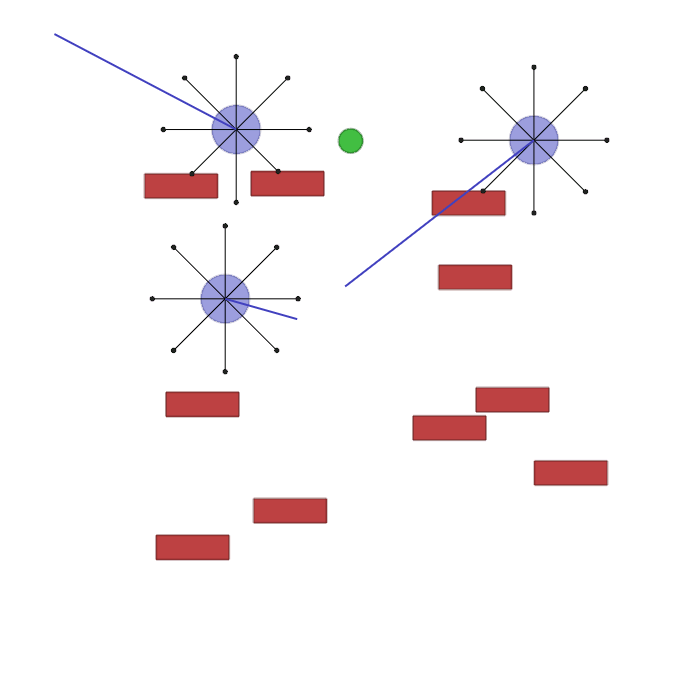

In [99]:
from IPython.display import Image
Image(f'{scenario_name}.gif')